# Experiment 8: Bayesian Model Training with Hyperparameter Optimization

This notebook implements Bayesian classification models on the startup founder retention dataset.
We'll use:
1. Naive Bayes (Gaussian, Multinomial, Bernoulli)
2. Bayesian Ridge Classifier
3. Optuna for hyperparameter optimization
4. Comprehensive evaluation metrics

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.linear_model import BayesianRidge
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve
)
import optuna
from optuna.visualization import (
    plot_optimization_history, plot_param_importances,
    plot_contour, plot_parallel_coordinate
)
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

/Users/aaryan/Desktop/binary/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Data Loading and Preprocessing

In [2]:
# Load datasets
train_df = pd.read_csv('../dataset/train_dropped_column.csv')
test_df = pd.read_csv('../dataset/test_dropped_column.csv')

print(f"Training data shape: {train_df.shape}")
print(f"Test data shape: {test_df.shape}")
print(f"\nTraining data columns: {train_df.columns.tolist()}")
print(f"\nTarget distribution:\n{train_df['retention_status'].value_counts()}")

Training data shape: (59608, 23)
Test data shape: (14900, 22)

Training data columns: ['founder_id', 'founder_age', 'founder_gender', 'years_with_startup', 'founder_role', 'monthly_revenue_generated', 'work_life_balance_rating', 'venture_satisfaction', 'startup_performance_rating', 'funding_rounds_led', 'working_overtime', 'distance_from_investor_hub', 'education_background', 'personal_status', 'num_dependents', 'startup_stage', 'team_size_category', 'remote_operations', 'leadership_scope', 'innovation_support', 'startup_reputation', 'founder_visibility', 'retention_status']

Target distribution:
retention_status
Stayed    31264
Left      28344
Name: count, dtype: int64


In [3]:
# Separate features and target
X_train = train_df.drop(['retention_status'], axis=1)
y_train = train_df['retention_status']
X_test = test_df.copy()

# Encode target variable
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)

print(f"Target classes: {le.classes_}")
print(f"Encoded as: {dict(zip(le.classes_, le.transform(le.classes_)))}")

Target classes: ['Left' 'Stayed']
Encoded as: {'Left': np.int64(0), 'Stayed': np.int64(1)}


In [4]:
# Identify categorical and numerical columns
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")
print(f"\nNumerical columns ({len(numerical_cols)}): {numerical_cols}")

Categorical columns (15): ['founder_gender', 'founder_role', 'work_life_balance_rating', 'venture_satisfaction', 'startup_performance_rating', 'working_overtime', 'education_background', 'personal_status', 'startup_stage', 'team_size_category', 'remote_operations', 'leadership_scope', 'innovation_support', 'startup_reputation', 'founder_visibility']

Numerical columns (7): ['founder_id', 'founder_age', 'years_with_startup', 'monthly_revenue_generated', 'funding_rounds_led', 'distance_from_investor_hub', 'num_dependents']


In [5]:
# Encode categorical variables
def encode_features(df, categorical_columns, label_encoders=None):
    """Encode categorical features using label encoding"""
    df_encoded = df.copy()
    
    if label_encoders is None:
        label_encoders = {}
        for col in categorical_columns:
            le = LabelEncoder()
            df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
            label_encoders[col] = le
    else:
        for col in categorical_columns:
            le = label_encoders[col]
            # Handle unseen categories
            df_encoded[col] = df_encoded[col].astype(str).apply(
                lambda x: le.transform([x])[0] if x in le.classes_ else -1
            )
    
    return df_encoded, label_encoders

X_train_encoded, feature_encoders = encode_features(X_train, categorical_cols)
X_test_encoded, _ = encode_features(X_test, categorical_cols, feature_encoders)

print(f"Encoded training data shape: {X_train_encoded.shape}")
print(f"Encoded test data shape: {X_test_encoded.shape}")

Encoded training data shape: (59608, 22)
Encoded test data shape: (14900, 22)


In [6]:
# Handle missing values
print(f"Missing values in training data:\n{X_train_encoded.isnull().sum()[X_train_encoded.isnull().sum() > 0]}")
print(f"\nMissing values in test data:\n{X_test_encoded.isnull().sum()[X_test_encoded.isnull().sum() > 0]}")

# Fill missing values with median for numerical columns
for col in numerical_cols:
    if X_train_encoded[col].isnull().any():
        median_val = X_train_encoded[col].median()
        X_train_encoded[col].fillna(median_val, inplace=True)
        X_test_encoded[col].fillna(median_val, inplace=True)

Missing values in training data:
Series([], dtype: int64)

Missing values in test data:
Series([], dtype: int64)


In [7]:
# Scale features for Bayesian models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

print(f"Scaled training data shape: {X_train_scaled.shape}")
print(f"Scaled test data shape: {X_test_scaled.shape}")

Scaled training data shape: (59608, 22)
Scaled test data shape: (14900, 22)


## 2. Baseline Models

In [8]:
# Train baseline Bayesian models
baseline_models = {
    'Gaussian NB': GaussianNB(),
    'Multinomial NB': MultinomialNB(),
    'Bernoulli NB': BernoulliNB()
}

baseline_results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name, model in baseline_models.items():
    print(f"\nTraining {name}...")
    
    # Use appropriate data (scaled for Gaussian, non-negative for Multinomial/Bernoulli)
    if name == 'Gaussian NB':
        X_data = X_train_scaled
    else:
        # Make data non-negative for Multinomial and Bernoulli
        X_data = X_train_encoded.values
        X_data = np.abs(X_data)  # Ensure non-negative
    
    # Cross-validation
    cv_scores = cross_val_score(model, X_data, y_train_encoded, cv=cv, scoring='accuracy')
    
    # Train on full data
    model.fit(X_data, y_train_encoded)
    
    baseline_results[name] = {
        'model': model,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'cv_scores': cv_scores
    }
    
    print(f"{name} - CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")


Training Gaussian NB...
Gaussian NB - CV Accuracy: 0.7075 (+/- 0.0054)

Training Multinomial NB...
Multinomial NB - CV Accuracy: 0.5095 (+/- 0.0061)

Training Bernoulli NB...
Bernoulli NB - CV Accuracy: 0.6609 (+/- 0.0068)


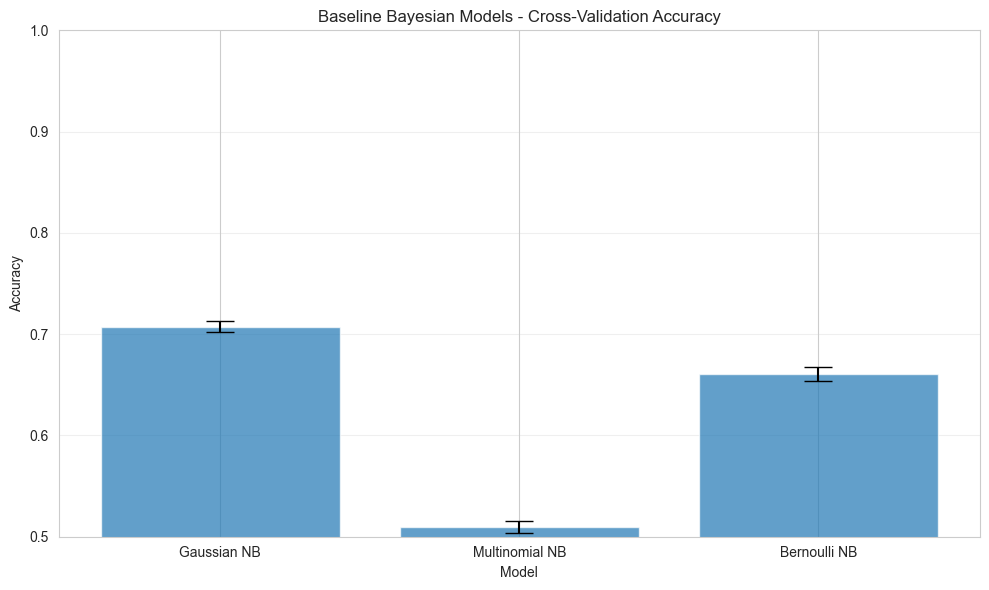

In [9]:
# Visualize baseline results
fig, ax = plt.subplots(figsize=(10, 6))

model_names = list(baseline_results.keys())
cv_means = [baseline_results[name]['cv_mean'] for name in model_names]
cv_stds = [baseline_results[name]['cv_std'] for name in model_names]

x_pos = np.arange(len(model_names))
ax.bar(x_pos, cv_means, yerr=cv_stds, align='center', alpha=0.7, capsize=10)
ax.set_ylabel('Accuracy')
ax.set_xlabel('Model')
ax.set_title('Baseline Bayesian Models - Cross-Validation Accuracy')
ax.set_xticks(x_pos)
ax.set_xticklabels(model_names)
ax.set_ylim([0.5, 1.0])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('baseline_models_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Hyperparameter Optimization with Optuna

In [10]:
# Optuna objective function for Gaussian Naive Bayes
def objective_gaussian_nb(trial):
    # Hyperparameters to tune
    var_smoothing = trial.suggest_float('var_smoothing', 1e-12, 1e-5, log=True)
    
    # Create model
    model = GaussianNB(var_smoothing=var_smoothing)
    
    # Cross-validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(model, X_train_scaled, y_train_encoded, cv=cv, scoring='accuracy')
    
    return scores.mean()

# Optimize Gaussian NB
print("Optimizing Gaussian Naive Bayes...")
study_gnb = optuna.create_study(direction='maximize', study_name='Gaussian_NB')
study_gnb.optimize(objective_gaussian_nb, n_trials=50, show_progress_bar=True)

print(f"\nBest trial:")
print(f"  Value (Accuracy): {study_gnb.best_trial.value:.4f}")
print(f"  Params: {study_gnb.best_trial.params}")

[I 2025-11-27 23:14:59,476] A new study created in memory with name: Gaussian_NB


Optimizing Gaussian Naive Bayes...


Best trial: 0. Best value: 0.707489:   2%|▏         | 1/50 [00:00<00:06,  8.02it/s]

[I 2025-11-27 23:14:59,611] Trial 0 finished with value: 0.7074887461956848 and parameters: {'var_smoothing': 3.310235484045095e-10}. Best is trial 0 with value: 0.7074887461956848.


Best trial: 0. Best value: 0.707489:   6%|▌         | 3/50 [00:00<00:04,  9.48it/s]

...

[I 2025-11-27 23:15:04,234] Trial 44 finished with value: 0.7074887461956848 and parameters: {'var_smoothing': 5.704808264382941e-07}. Best is trial 0 with value: 0.7074887461956848.
[I 2025-11-27 23:15:04,336] Trial 45 finished with value: 0.7074887461956848 and parameters: {'var_smoothing': 1.1078195180548965e-09}. Best is trial 0 with value: 0.7074887461956848.


Best trial: 0. Best value: 0.707489:  96%|█████████▌| 48/50 [00:05<00:00,  9.40it/s]

[I 2025-11-27 23:15:04,443] Trial 46 finished with value: 0.7074887461956848 and parameters: {'var_smoothing': 1.5595109738344045e-11}. Best is trial 0 with value: 0.7074887461956848.
[I 2025-11-27 23:15:04,553] Trial 47 finished with value: 0.7074887461956848 and parameters: {'var_smoothing': 1.1450523335436076e-12}. Best is trial 0 with value: 0.7074887461956848.


Best trial: 0. Best value: 0.707489: 100%|██████████| 50/50 [00:05<00:00,  9.42it/s]

[I 2025-11-27 23:15:04,689] Trial 48 finished with value: 0.7074887461956848 and parameters: {'var_smoothing': 1.6770962167502802e-10}. Best is trial 0 with value: 0.7074887461956848.
[I 2025-11-27 23:15:04,796] Trial 49 finished with value: 0.7074887461956848 and parameters: {'var_smoothing': 3.4397057167821226e-10}. Best is trial 0 with value: 0.7074887461956848.

Best trial:
  Value (Accuracy): 0.7075
  Params: {'var_smoothing': 3.310235484045095e-10}


In [11]:
# Optuna objective function for Multinomial Naive Bayes
def objective_multinomial_nb(trial):
    # Hyperparameters to tune
    alpha = trial.suggest_float('alpha', 0.01, 10.0, log=True)
    fit_prior = trial.suggest_categorical('fit_prior', [True, False])
    
    # Create model
    model = MultinomialNB(alpha=alpha, fit_prior=fit_prior)
    
    # Prepare non-negative data
    X_data = np.abs(X_train_encoded.values)
    
    # Cross-validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(model, X_data, y_train_encoded, cv=cv, scoring='accuracy')
    
    return scores.mean()

# Optimize Multinomial NB
print("Optimizing Multinomial Naive Bayes...")
study_mnb = optuna.create_study(direction='maximize', study_name='Multinomial_NB')
study_mnb.optimize(objective_multinomial_nb, n_trials=50, show_progress_bar=True)

print(f"\nBest trial:")
print(f"  Value (Accuracy): {study_mnb.best_trial.value:.4f}")
print(f"  Params: {study_mnb.best_trial.params}")

[I 2025-11-27 23:15:18,669] A new study created in memory with name: Multinomial_NB


Optimizing Multinomial Naive Bayes...


Best trial: 0. Best value: 0.509546:   4%|▍         | 2/50 [00:00<00:03, 13.79it/s]

[I 2025-11-27 23:15:18,758] Trial 0 finished with value: 0.5095455359031198 and parameters: {'alpha': 0.29247431580379607, 'fit_prior': False}. Best is trial 0 with value: 0.5095455359031198.
[I 2025-11-27 23:15:18,816] Trial 1 finished with value: 0.5094784358825051 and parameters: {'alpha': 0.04553843983543087, 'fit_prior': True}. Best is trial 0 with value: 0.5095455359031198.


Best trial: 0. Best value: 0.509546:   8%|▊         | 4/50 [00:00<00:02, 15.51it/s]

...

[I 2025-11-27 23:15:21,835] Trial 45 finished with value: 0.5095455359031198 and parameters: {'alpha': 2.062472735977772, 'fit_prior': False}. Best is trial 0 with value: 0.5095455359031198.
[I 2025-11-27 23:15:21,900] Trial 46 finished with value: 0.5095455359031198 and parameters: {'alpha': 0.588720043861189, 'fit_prior': False}. Best is trial 0 with value: 0.5095455359031198.
[I 2025-11-27 23:15:21,964] Trial 47 finished with value: 0.5095455359031198 and parameters: {'alpha': 3.6501862735890698, 'fit_prior': False}. Best is trial 0 with value: 0.5095455359031198.


Best trial: 0. Best value: 0.509546:  96%|█████████▌| 48/50 [00:03<00:00, 15.76it/s]

[I 2025-11-27 23:15:22,030] Trial 48 finished with value: 0.5095455359031198 and parameters: {'alpha': 0.8923887406612223, 'fit_prior': False}. Best is trial 0 with value: 0.5095455359031198.


Best trial: 0. Best value: 0.509546: 100%|██████████| 50/50 [00:03<00:00, 14.39it/s]

[I 2025-11-27 23:15:22,145] Trial 49 finished with value: 0.5094616601737314 and parameters: {'alpha': 8.500725988083856, 'fit_prior': True}. Best is trial 0 with value: 0.5095455359031198.

Best trial:
  Value (Accuracy): 0.5095
  Params: {'alpha': 0.29247431580379607, 'fit_prior': False}


In [12]:
# Optuna objective function for Bernoulli Naive Bayes
def objective_bernoulli_nb(trial):
    # Hyperparameters to tune
    alpha = trial.suggest_float('alpha', 0.01, 10.0, log=True)
    binarize = trial.suggest_float('binarize', 0.0, 1.0)
    fit_prior = trial.suggest_categorical('fit_prior', [True, False])
    
    # Create model
    model = BernoulliNB(alpha=alpha, binarize=binarize, fit_prior=fit_prior)
    
    # Prepare non-negative data
    X_data = np.abs(X_train_encoded.values)
    
    # Cross-validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(model, X_data, y_train_encoded, cv=cv, scoring='accuracy')
    
    return scores.mean()

# Optimize Bernoulli NB
print("Optimizing Bernoulli Naive Bayes...")
study_bnb = optuna.create_study(direction='maximize', study_name='Bernoulli_NB')
study_bnb.optimize(objective_bernoulli_nb, n_trials=50, show_progress_bar=True)

print(f"\nBest trial:")
print(f"  Value (Accuracy): {study_bnb.best_trial.value:.4f}")
print(f"  Params: {study_bnb.best_trial.params}")

[I 2025-11-27 23:15:27,264] A new study created in memory with name: Bernoulli_NB


Optimizing Bernoulli Naive Bayes...


Best trial: 0. Best value: 0.660935:   2%|▏         | 1/50 [00:00<00:07,  6.26it/s]

[I 2025-11-27 23:15:27,427] Trial 0 finished with value: 0.6609346373438929 and parameters: {'alpha': 0.013216352509415344, 'binarize': 0.9832196984169466, 'fit_prior': True}. Best is trial 0 with value: 0.6609346373438929.


Best trial: 0. Best value: 0.660935:   4%|▍         | 2/50 [00:00<00:06,  6.96it/s]

...

[I 2025-11-27 23:15:33,889] Trial 47 finished with value: 0.6604312999403992 and parameters: {'alpha': 2.3293405198889423, 'binarize': 0.03547819630002615, 'fit_prior': False}. Best is trial 8 with value: 0.6609514144599067.


Best trial: 8. Best value: 0.660951:  98%|█████████▊| 49/50 [00:06<00:00,  6.89it/s]

[I 2025-11-27 23:15:34,031] Trial 48 finished with value: 0.6609178630423593 and parameters: {'alpha': 1.3192843665474627, 'binarize': 0.11798077843450255, 'fit_prior': True}. Best is trial 8 with value: 0.6609514144599067.


Best trial: 8. Best value: 0.660951: 100%|██████████| 50/50 [00:06<00:00,  7.24it/s]

[I 2025-11-27 23:15:34,169] Trial 49 finished with value: 0.6609346373438929 and parameters: {'alpha': 0.1931976342976144, 'binarize': 0.04782514307070439, 'fit_prior': True}. Best is trial 8 with value: 0.6609514144599067.

Best trial:
  Value (Accuracy): 0.6610
  Params: {'alpha': 0.6603949561417082, 'binarize': 0.025643447398429386, 'fit_prior': True}


## 4. Visualization of Optimization Results

In [13]:
# Optimization history for Gaussian NB
fig = plot_optimization_history(study_gnb)
fig.update_layout(title='Gaussian NB - Optimization History')
fig.write_image('gnb_optimization_history.png')
fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [ ]:
# Parameter importance for Multinomial NB
fig = plot_param_importances(study_mnb)
fig.update_layout(title='Multinomial NB - Parameter Importances')
fig.write_image('mnb_param_importances.png')
fig.show()

In [ ]:
# Parallel coordinate plot for Bernoulli NB
fig = plot_parallel_coordinate(study_bnb)
fig.update_layout(title='Bernoulli NB - Parallel Coordinate Plot')
fig.write_image('bnb_parallel_coordinate.png')
fig.show()

## 5. Train Best Models

In [ ]:
# Train best models with optimized hyperparameters
best_models = {}

# Gaussian NB
best_gnb = GaussianNB(**study_gnb.best_params)
best_gnb.fit(X_train_scaled, y_train_encoded)
best_models['Gaussian NB (Optimized)'] = best_gnb

# Multinomial NB
best_mnb = MultinomialNB(**study_mnb.best_params)
X_train_nonneg = np.abs(X_train_encoded.values)
best_mnb.fit(X_train_nonneg, y_train_encoded)
best_models['Multinomial NB (Optimized)'] = best_mnb

# Bernoulli NB
best_bnb = BernoulliNB(**study_bnb.best_params)
best_bnb.fit(X_train_nonneg, y_train_encoded)
best_models['Bernoulli NB (Optimized)'] = best_bnb

print("Best models trained successfully!")

## 6. Model Evaluation

In [ ]:
# Evaluate models on training data
evaluation_results = {}

for name, model in best_models.items():
    print(f"\nEvaluating {name}...")
    
    # Select appropriate data
    if 'Gaussian' in name:
        X_eval = X_train_scaled
    else:
        X_eval = X_train_nonneg
    
    # Predictions
    y_pred = model.predict(X_eval)
    y_pred_proba = model.predict_proba(X_eval)[:, 1]
    
    # Metrics
    accuracy = accuracy_score(y_train_encoded, y_pred)
    precision = precision_score(y_train_encoded, y_pred)
    recall = recall_score(y_train_encoded, y_pred)
    f1 = f1_score(y_train_encoded, y_pred)
    roc_auc = roc_auc_score(y_train_encoded, y_pred_proba)
    
    evaluation_results[name] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")

In [ ]:
# Create evaluation metrics comparison
metrics_df = pd.DataFrame(evaluation_results).T
metrics_df = metrics_df[['accuracy', 'precision', 'recall', 'f1', 'roc_auc']]

print("\nModel Comparison:")
print(metrics_df.round(4))

# Save to CSV
metrics_df.to_csv('model_evaluation_metrics.csv')

In [ ]:
# Visualize metrics comparison
fig, ax = plt.subplots(figsize=(14, 6))

metrics_df.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Model Performance Comparison', fontsize=16, fontweight='bold')
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim([0, 1])
ax.legend(title='Metrics', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('model_metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, results) in enumerate(evaluation_results.items()):
    cm = confusion_matrix(y_train_encoded, results['y_pred'])
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=le.classes_, yticklabels=le.classes_)
    axes[idx].set_title(f'{name}\nConfusion Matrix', fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# ROC Curves
fig, ax = plt.subplots(figsize=(10, 8))

for name, results in evaluation_results.items():
    fpr, tpr, _ = roc_curve(y_train_encoded, results['y_pred_proba'])
    roc_auc = results['roc_auc']
    ax.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves - Model Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Precision-Recall Curves
fig, ax = plt.subplots(figsize=(10, 8))

for name, results in evaluation_results.items():
    precision_curve, recall_curve, _ = precision_recall_curve(y_train_encoded, results['y_pred_proba'])
    ax.plot(recall_curve, precision_curve, lw=2, label=name)

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves - Model Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='lower left', fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('precision_recall_curves.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Select Best Model and Generate Predictions

In [ ]:
# Select best model based on F1 score
best_model_name = max(evaluation_results.items(), key=lambda x: x[1]['f1'])[0]
best_model = best_models[best_model_name]

print(f"Best Model: {best_model_name}")
print(f"\nPerformance Metrics:")
for metric, value in evaluation_results[best_model_name].items():
    if metric not in ['y_pred', 'y_pred_proba']:
        print(f"  {metric}: {value:.4f}")

In [ ]:
# Generate predictions on test set
if 'Gaussian' in best_model_name:
    X_test_final = X_test_scaled
else:
    X_test_final = np.abs(X_test_encoded.values)

test_predictions = best_model.predict(X_test_final)
test_predictions_proba = best_model.predict_proba(X_test_final)[:, 1]

# Convert predictions back to original labels
test_predictions_labels = le.inverse_transform(test_predictions)

print(f"Test predictions shape: {test_predictions.shape}")
print(f"\nPrediction distribution:")
print(pd.Series(test_predictions_labels).value_counts())

In [ ]:
# Create submission file
submission_df = pd.DataFrame({
    'founder_id': test_df['founder_id'],
    'retention_status': test_predictions_labels,
    'prediction_probability': test_predictions_proba
})

# Save submission
submission_df[['founder_id', 'retention_status']].to_csv('bayesian_submission.csv', index=False)
submission_df.to_csv('bayesian_submission_with_proba.csv', index=False)

print("Submission files created:")
print("  - bayesian_submission.csv")
print("  - bayesian_submission_with_proba.csv")
print(f"\nFirst few predictions:")
print(submission_df.head(10))

## 8. Summary and Insights

In [ ]:
# Create summary report
summary = f"""
=== BAYESIAN MODEL TRAINING SUMMARY ===

Dataset Information:
- Training samples: {len(X_train)}
- Test samples: {len(X_test)}
- Number of features: {X_train.shape[1]}
- Target classes: {le.classes_}

Models Evaluated:
1. Gaussian Naive Bayes (Optimized)
2. Multinomial Naive Bayes (Optimized)
3. Bernoulli Naive Bayes (Optimized)

Best Model: {best_model_name}

Best Model Performance:
- Accuracy: {evaluation_results[best_model_name]['accuracy']:.4f}
- Precision: {evaluation_results[best_model_name]['precision']:.4f}
- Recall: {evaluation_results[best_model_name]['recall']:.4f}
- F1 Score: {evaluation_results[best_model_name]['f1']:.4f}
- ROC AUC: {evaluation_results[best_model_name]['roc_auc']:.4f}

Hyperparameter Optimization:
- Optimization trials per model: 50
- Cross-validation folds: 5

Best Hyperparameters:
"""

if 'Gaussian' in best_model_name:
    summary += f"- Gaussian NB: {study_gnb.best_params}\n"
elif 'Multinomial' in best_model_name:
    summary += f"- Multinomial NB: {study_mnb.best_params}\n"
else:
    summary += f"- Bernoulli NB: {study_bnb.best_params}\n"

summary += f"""
Output Files:
- bayesian_submission.csv
- bayesian_submission_with_proba.csv
- model_evaluation_metrics.csv
- Various visualization plots

=== END OF SUMMARY ===
"""

print(summary)

# Save summary to file
with open('bayesian_model_summary.txt', 'w') as f:
    f.write(summary)

In [ ]:
# Save all study objects for future reference
import pickle

studies = {
    'gaussian_nb': study_gnb,
    'multinomial_nb': study_mnb,
    'bernoulli_nb': study_bnb
}

with open('optuna_studies.pkl', 'wb') as f:
    pickle.dump(studies, f)

print("Optuna studies saved to 'optuna_studies.pkl'")

In [ ]:
print("\n" + "="*50)
print("BAYESIAN MODEL TRAINING COMPLETED SUCCESSFULLY!")
print("="*50)